# Visualize Natural Scenes Spike Trains

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import numpy as np
import visionloader as vl
import rawmovie
import matplotlib.pyplot as plt
import os
import cvxpy as cp

In [2]:
piece = '2018-08-07-5'
analysis_base = f"/Volumes/Analysis/{piece}"

wnoise = "data000"
nscenes = "data001"
cell_types = ['ON parasol', 'OFF parasol']

wnoise_path = os.path.join(analysis_base, wnoise)
nscenes_path = os.path.join(analysis_base, nscenes)

In [3]:
from matplotlib.patches import Ellipse

def find_cell_mapping(datapath1,datapath2,data1,data2,correlation_threshold=0.95,c_types=None,plot=True):
    """
    Map cell IDs between different visual stimulation runs.

    Parameters:
        piece: experiment piece
        data1: first visual stim
        data2: second visual stim
        correlation_threshold: lower limit on acceptable cell match
        cell_types: list of cell types to map

    Returns:
        mapping: dictionary with forward and reverse cell ID maps
    """

    vcd1 = vl.load_vision_data(datapath1,data1,
                            include_neurons=True,
                            include_ei=True,
                            include_params=True,
                            include_runtimemovie_params=True)

    vcd2 = vl.load_vision_data(datapath2,data2,
                            include_neurons=True,
                            include_ei=True,
                            include_params=True)

    if c_types is None:
        c_types = ['ON Parasol', 'OFF Parasol', 'ON Midget', 'OFF Midget']

    mapping = {'forward':{}, 'backward':{}}

    # Loop over cell IDs in first vstim and check against each cell ID in second vstim
    for cell_type in c_types:
        cells_of_interest1 = vcd1.get_all_cells_similar_to_type(cell_type)
        cells_of_interest2 = vcd2.get_cell_ids()
        mapped_cells_of_interest = 0

        for c1 in cells_of_interest1:
            ei1 = vcd1.get_ei_for_cell(c1).ei
            # Compute total power at each electrode from EI
            electrode_power1 = np.sum(np.square(ei1),axis=1)

            corrs = np.zeros(len(cells_of_interest2))

            for i, c2 in enumerate(cells_of_interest2):
                ei2 = vcd2.get_ei_for_cell(c2).ei
                # Compute total power at each electrode from EI
                electrode_power2 = np.sum(np.square(ei2),axis=1)
                # Compute Pearson correlation coefficient between cells
                corrs[i] = np.corrcoef(electrode_power1,electrode_power2)[0,1]

            cell_match_index = np.argmax(corrs)

            # Enter best match if it surpasses correlation threshold
            if corrs[cell_match_index] > correlation_threshold:
                mapping['forward'][c1] = cells_of_interest2[cell_match_index]
                mapping['backward'][cells_of_interest2[cell_match_index]] = c1
                
                # Remove from consideration so that multiple cells are not matched to this one
                cells_of_interest2.pop(cell_match_index)
                mapped_cells_of_interest += 1

        print(f"{mapped_cells_of_interest} out of {len(cells_of_interest1)} {cell_type} cells were successfully mapped")

        if plot:
            fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))
            assert(vcd1.get_runtimemovie_params().pixelsPerStixelX == vcd1.get_runtimemovie_params().pixelsPerStixelY)
            # assert(vcd2.get_runtimemovie_params().pixelsPerStixelX == vcd2.get_runtimemovie_params().pixelsPerStixelY)
            STIXEL1 = vcd1.get_runtimemovie_params().pixelsPerStixelX
            # STIXEL2 = vcd2.get_runtimemovie_params().pixelsPerStixelX

            for c1 in cells_of_interest1:
                center_x = STIXEL1 * vcd1.get_stafit_for_cell(c1).center_x
                center_y = STIXEL1 * (int(vcd1.get_runtimemovie_params().height) - vcd1.get_stafit_for_cell(c1).center_y)
                std_x = STIXEL1 * vcd1.get_stafit_for_cell(c1).std_x
                std_y = STIXEL1 * vcd1.get_stafit_for_cell(c1).std_y
                rot = vcd1.get_stafit_for_cell(c1).rot

                rf1 = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=-rot*180/np.pi, fill=True)

                if c1 in mapping['forward']:
                    rf1.set_facecolor('green')
                else:
                    rf1.set_facecolor('red')
                
                ax.add_patch(rf1)

            ax.set_xlim(0, 640-1)
            ax.set_ylim(0, 320-1)
            ax.set_aspect('equal')
            ax.set_title(cell_type)
            ax.xaxis.set_visible(False)
            ax.yaxis.set_visible(False)

            plt.show()

    return mapping

73 out of 76 ON Parasol cells were successfully mapped


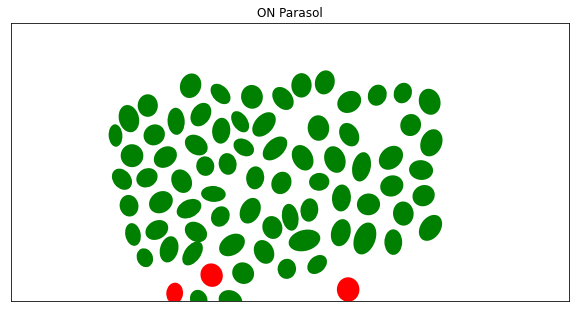

94 out of 106 OFF Parasol cells were successfully mapped


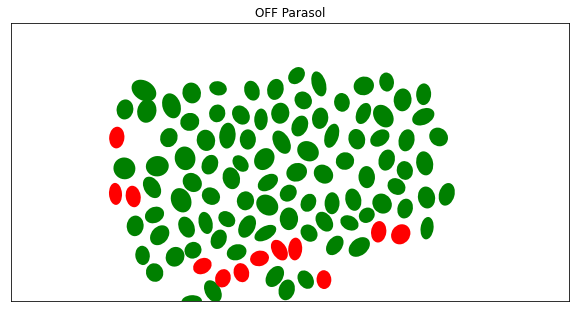

In [4]:
mapping = find_cell_mapping(wnoise_path,nscenes_path,wnoise,nscenes,correlation_threshold=0.7,c_types=['ON Parasol', 'OFF Parasol'],plot=True)

In [5]:
vcd = vl.load_vision_data(nscenes_path,nscenes,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True)

ttl_times = vcd.get_ttl_times()/20000
np.set_printoptions(suppress=True)
print(ttl_times[:10])

[0.0535  0.5238  1.03395 1.52785 2.0215  2.53185 3.0256  3.536   4.0297
 4.5399 ]


In [6]:
imagenet = rawmovie.RawMovieReader(f"/Volumes/Data/Stimuli/imagenet/ImageNet_stix2_0_045.rawMovie")
imagenet_frames, _ = imagenet.get_all_frames() # All color channels are the same

imagenet_test = rawmovie.RawMovieReader(f"/Volumes/Data/Stimuli/imagenet/ImageNetTest_v2.rawMovie")
imagenet_test_frames, _ = imagenet_test.get_all_frames() # All color channels are the same

(160, 320, 3)


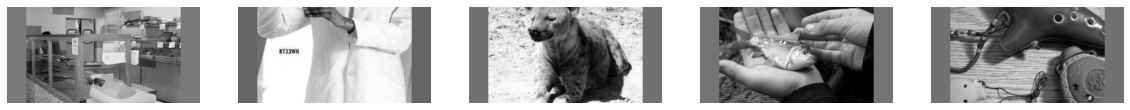

In [7]:
print(imagenet_frames[0].shape)

# plot just the first color channel for the first 5 frames
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    ax[i].imshow(imagenet_frames[i][:,:,0], cmap='gray')
    ax[i].axis('off')
plt.show()

In [8]:
def get_spike_times(vcd, cell_ids):

    spike_times = np.array([vcd.get_spike_times_for_cell(c) for c in cell_ids], dtype=object)
    spike_times /= 20

    return spike_times

def round_spike_times(vcd, cell_ids, bin_size_ms):

    sample_size = bin_size_ms * 20 
    rounded_spike_times = np.array([np.round(vcd.get_spike_times_for_cell(c) / sample_size) * sample_size for c in cell_ids], dtype=object)
    rounded_spike_times /= 20

    return rounded_spike_times

In [9]:
cell_ids = np.array(list(mapping['forward'].values()))#[np.random.randint(0, len(mapping['forward']), 30)]

spike_times = get_spike_times(vcd, cell_ids)
print(spike_times.shape)

bin_size_ms = 2.5
rounded_spike_times = round_spike_times(vcd, cell_ids, bin_size_ms)
print(rounded_spike_times.shape)

(167,)
(167,)


In [10]:
low = 0
high = 1000

filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
filtered_rounded_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in rounded_spike_times], dtype=object)

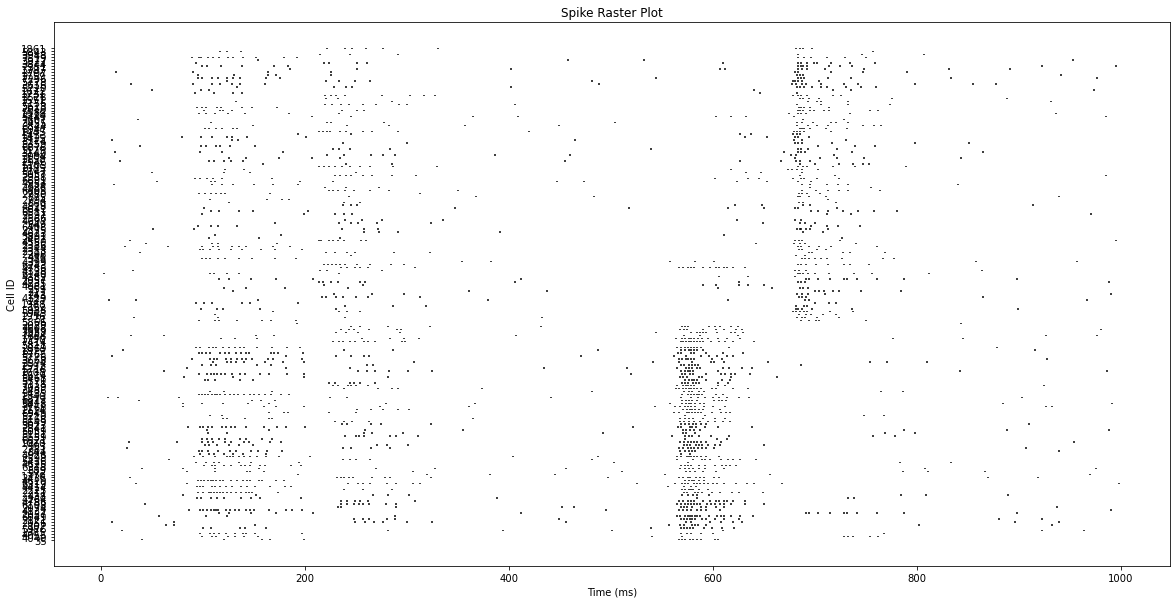

In [11]:
plt.figure(figsize=(20, 10))

# Create a spike raster plot
plt.eventplot(filtered_spike_times, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Spike Raster Plot')

# Show the plot
plt.show()


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # Change the figsize as desired

# Plot the filtered spike times
axs[0].eventplot(filtered_spike_times, linelengths=0.5, colors='black')
axs[0].set_yticks(range(len(cell_ids)))
axs[0].set_yticklabels(cell_ids)
axs[0].set_ylabel('Cell ID')
axs[0].set_xlabel('Time (ms)')
axs[0].set_title('Filtered Spike Raster Plot')

# Plot the filtered rounded spike times
axs[1].eventplot(filtered_rounded_spike_times, linelengths=0.5, colors='black')
axs[1].set_yticks(range(len(cell_ids)))
axs[1].set_yticklabels(cell_ids)
axs[1].set_ylabel('Cell ID')
axs[1].set_xlabel('Time (ms)')
axs[1].set_title('Filtered Rounded Spike Raster Plot')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

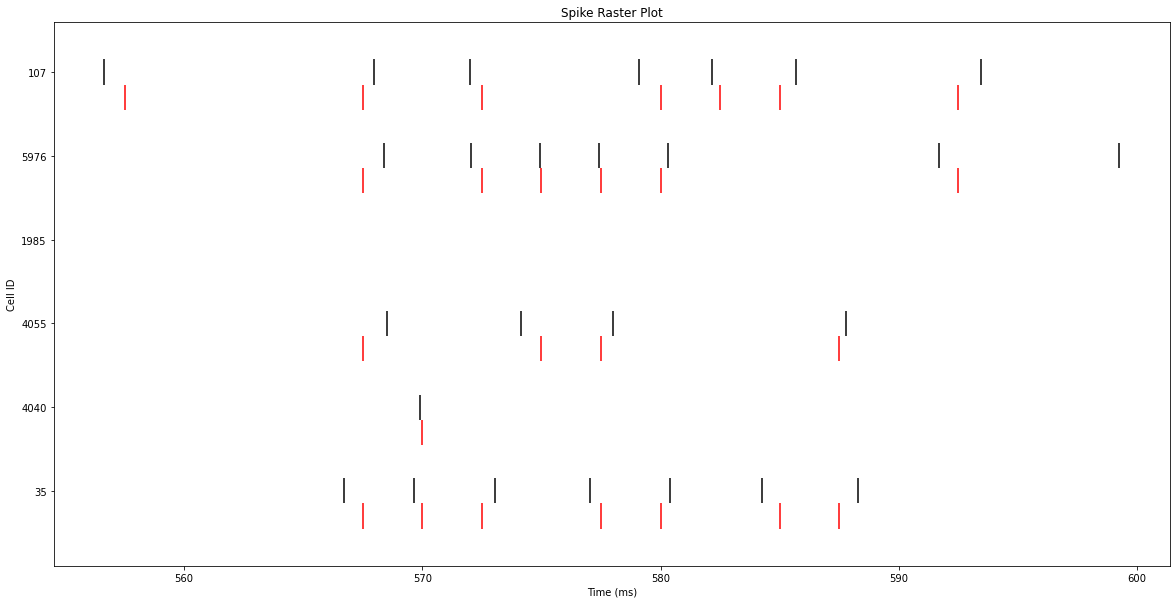

In [104]:
plt.figure(figsize=(20, 10))

# Make two lineoffsets vectors offset by a constant value
lineoffsets1 = np.arange(len(cell_ids))
lineoffsets2 = np.arange(len(cell_ids)) - 0.3

# Create a spike raster plot
plt.eventplot(filtered_spike_times, linelengths=0.3, lineoffsets=lineoffsets1, colors='black')
plt.eventplot(filtered_rounded_spike_times, linelengths=0.3, lineoffsets=lineoffsets2, colors='red')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Spike Raster Plot')

# Show the plot
plt.show()

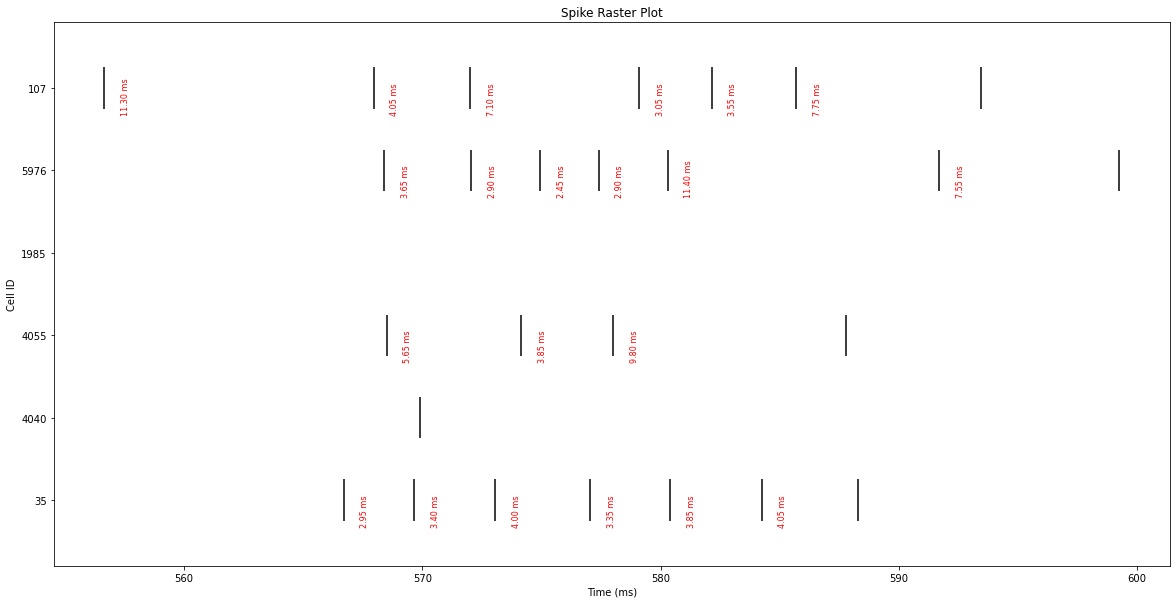

In [105]:
plt.figure(figsize=(20, 10))

# Create a spike raster plot
plt.eventplot(filtered_spike_times, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Spike Raster Plot')

# Annotate the time difference between consecutive spikes
for i, spikes in enumerate(filtered_spike_times):
    for j in range(len(spikes) - 1):
        time_diff = spikes[j+1] - spikes[j]
        plt.annotate(f'{time_diff:.2f} ms', xy=(spikes[j], i), xytext=(spikes[j]+0.7, i-0.3), fontsize=8, rotation=90, color='red')

# Show the plot
plt.show()

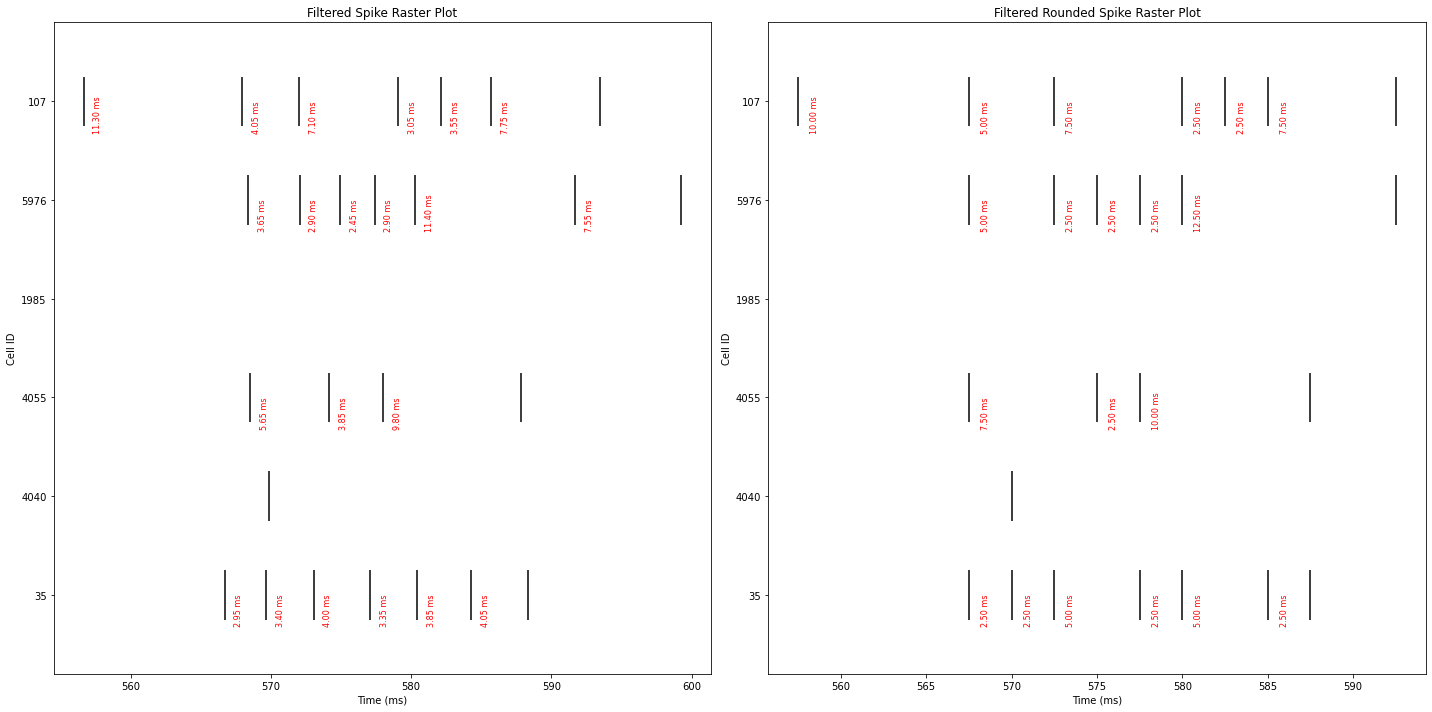

In [106]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # Change the figsize as desired

# Plot the filtered spike times
axs[0].eventplot(filtered_spike_times, linelengths=0.5, colors='black')
axs[0].set_yticks(range(len(cell_ids)))
axs[0].set_yticklabels(cell_ids)
axs[0].set_ylabel('Cell ID')
axs[0].set_xlabel('Time (ms)')
axs[0].set_title('Filtered Spike Raster Plot')

# Annotate the time difference between consecutive spikes
for i, spikes in enumerate(filtered_spike_times):
    for j in range(len(spikes) - 1):
        time_diff = spikes[j+1] - spikes[j]
        axs[0].annotate(f'{time_diff:.2f} ms', xy=(spikes[j], i), xytext=(spikes[j]+0.7, i-0.3), fontsize=8, rotation=90, color='red')

# Plot the filtered rounded spike times
axs[1].eventplot(filtered_rounded_spike_times, linelengths=0.5, colors='black')
axs[1].set_yticks(range(len(cell_ids)))
axs[1].set_yticklabels(cell_ids)
axs[1].set_ylabel('Cell ID')
axs[1].set_xlabel('Time (ms)')
axs[1].set_title('Filtered Rounded Spike Raster Plot')

# Annotate the time difference between consecutive spikes
for i, spikes in enumerate(filtered_rounded_spike_times):
    for j in range(len(spikes) - 1):
        time_diff = spikes[j+1] - spikes[j]
        axs[1].annotate(f'{time_diff:.2f} ms', xy=(spikes[j], i), xytext=(spikes[j]+0.7, i-0.3), fontsize=8, rotation=90, color='red')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

In [94]:
min_interspike_interval = np.array([np.min(np.diff(cell_spike_times)) for cell_spike_times in spike_times])
average_interspike_interval = np.array([np.mean(np.diff(cell_spike_times)) for cell_spike_times in spike_times])
average_spike_rate = np.array([len(cell_spike_times) / (vcd.get_n_samples()/20000) for cell_spike_times in spike_times])

proportions = []
for cell_spike_times in spike_times:
    intervals = np.diff(cell_spike_times)
    proportion = np.mean(intervals < 2.5)
    proportions.append(proportion)
proportions = np.array(proportions)

print("Minimum Interspike Interval:")
print(min_interspike_interval)
print(np.mean(min_interspike_interval))

print("Average Interspike Interval:")
print(average_interspike_interval)
print(np.mean(average_interspike_interval))

print("Percentage of Interspike Intervals < 2.5 ms:")
print(proportions*100)
print(np.mean(proportions)*100)

print("Average Spike Rate:")
print(average_spike_rate)
print(np.mean(average_spike_rate))

Minimum Interspike Interval:
[1.85 1.3  1.85 0.3  2.   2.1  1.45 2.   1.05 0.4  1.7  1.95 1.9  0.4
 1.7  1.85 0.5  2.   0.3  2.   1.8  1.9  0.7  0.95 2.   1.85 2.05 0.3
 0.95 1.85 1.75 1.95 1.8  1.95 2.3  0.9  1.9  1.9  1.   2.   1.95 1.8
 1.95 1.9  1.4  2.   1.85 1.85 0.55 0.75 1.05 1.95 2.   0.85 1.8  1.85
 2.1  1.9  0.75 0.3  2.1  1.9  0.3  1.85 1.85 1.8  7.85 1.8  2.05 0.65
 2.   2.   1.9  0.95 1.1  0.95 0.75 1.75 1.2  1.9  0.3  1.15 1.9  1.2
 0.5  2.   0.9  1.85 0.4  1.85 1.75 1.8  0.4  1.1  0.8  0.45 0.4  0.55
 1.05 1.75 0.75 1.75 0.6  1.   0.8  0.3  0.75 0.4  2.   0.4  1.   0.4
 0.8  1.85 1.15 0.95 2.   0.75 1.05 0.4  0.3  1.05 1.85 0.85 1.8  1.55
 1.75 1.8  0.3  1.9  0.8  1.8  2.05 0.7  1.9  2.05 1.9  1.5  1.75 1.9
 0.6  2.   1.25 1.65 2.05 0.75 2.05 0.85 2.   0.7  2.   1.35 0.35 1.95
 1.1  0.75 1.   2.1  1.7  0.3  1.4  0.9  0.85 0.5  1.2  1.65 1.9 ]
1.396407185595395
Average Interspike Interval:
[ 70.36425171  68.10555134  78.26015408 125.61435562  73.82004763
  70.31045503  6

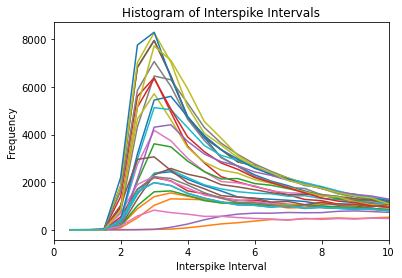

In [90]:
# Calculate the histogram of interspike intervals for each cell
histograms = [np.histogram(np.diff(cell_spike_times), bins=np.arange(1,1000)/2, density=False) for cell_spike_times in spike_times]

# Plot the distribution of interspike intervals for each cell
for histogram in histograms:
    plt.plot(histogram[1][:-1], histogram[0])

# Set the x-axis limits
plt.xlim(0, 10)

# Set the x-axis label
plt.xlabel('Interspike Interval')

# Set the y-axis label
plt.ylabel('Frequency')

# Set the plot title
plt.title('Histogram of Interspike Intervals')

# Show the plot
plt.show()
